## Swiggy Sales Analysis

**Objectives:**
  
- Analyze revenue performance.
- Identify top-performing cities and states.
- Track quarterly sales trends.
- Analyze weekly revenue patterns.

In [86]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df=pd.read_csv("swiggy_data.csv")
df.head()

,State,City,Order Date,Restaurant Name,Location,Category,Dish Name,Price (INR),Rating,Rating Count
0,Karnataka,Bengaluru,29-06-2025,Anand Sweets & Savouries,Rajarajeshwari Nagar,Snack,Butter Murukku-200gm,133.9,4.0,0
1,Karnataka,Bengaluru,03-04-2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Badam Milk,52.0,4.5,25
2,Karnataka,Bengaluru,15-01-2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Chow Chow Bath,117.0,4.7,48
3,Karnataka,Bengaluru,17-04-2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Kesari Bath,65.0,4.6,65
4,Karnataka,Bengaluru,13-03-2025,Srinidhi Sagar Deluxe,Kengeri,Recommended,Mix Raitha,130.0,4.0,0


In [62]:
df.shape

(197430, 10)

In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 197430 entries, 0 to 197429
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   State            197430 non-null  object 
 1   City             197430 non-null  object 
 2   Order Date       197430 non-null  object 
 3   Restaurant Name  197430 non-null  object 
 4   Location         197430 non-null  object 
 5   Category         197430 non-null  object 
 6   Dish Name        197430 non-null  object 
 7   Price (INR)      197430 non-null  float64
 8   Rating           197430 non-null  float64
 9   Rating Count     197430 non-null  int64  
dtypes: float64(2), int64(1), object(7)
memory usage: 15.1+ MB


In [64]:
df.isnull().sum()

State              0
City               0
Order Date         0
Restaurant Name    0
Location           0
Category           0
Dish Name          0
Price (INR)        0
Rating             0
Rating Count       0
dtype: int64

In [65]:
df["Order Date"]=pd.to_datetime(df["Order Date"])

C:\Users\amiko\AppData\Local\Temp\ipykernel_26252\3409388657.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Order Date"]=pd.to_datetime(df["Order Date"])


In [66]:
df.describe()

,Order Date,Price (INR),Rating,Rating Count
count,197430,197430.000000,197430.000000,197430.000000
mean,2025-05-01 19:41:20.996808960,268.512920,4.341582,28.321805
min,2025-01-01 00:00:00,0.950000,1.500000,0.000000
25%,2025-03-01 00:00:00,139.000000,4.300000,0.000000
50%,2025-05-02 00:00:00,229.000000,4.400000,2.000000
75%,2025-07-01 00:00:00,329.000000,4.500000,15.000000
max,2025-08-31 00:00:00,8000.000000,5.000000,999.000000
std,NaN,219.338363,0.422585,87.542593


In [67]:
df.columns

Index(['State', 'City', 'Order Date', 'Restaurant Name', 'Location',
       'Category', 'Dish Name', 'Price (INR)', 'Rating', 'Rating Count'],
      dtype='object')

In [68]:
df.duplicated().sum()

np.int64(27)

In [69]:
df.drop_duplicates(inplace=True)

In [70]:
df.shape

(197403, 10)

### KPI's

**Total Sales**

In [71]:
total_sales=df["Price (INR)"].sum()
print("Total Sales: ",total_sales)

Total Sales:  53002984.47


**Average Rating**

In [72]:
average_rating=df["Rating"].mean()
print("Average Rating: ",round(average_rating,1))

Average Rating:  4.3


**Average Order Value**

In [73]:
avg_order_value=df["Price (INR)"].mean()
print("Total Sales: ",round(avg_order_value,2))

Total Sales:  268.5


**Ratings Count**

In [74]:
ratings_count=df["Rating Count"].sum()
print("Ratings Count: ",ratings_count)

Ratings Count:  5591171


**Total Orders**

In [75]:
total_orders=df.shape[0]
print("Total Orders: ",total_orders)

Total Orders:  197403


### Charts

**Monthly Sales Trend**

In [76]:
df["YearMonth"]=df["Order Date"].dt.to_period("M").astype(str)

monthly_revenue=df.groupby("YearMonth")["Price (INR)"].sum().reset_index()



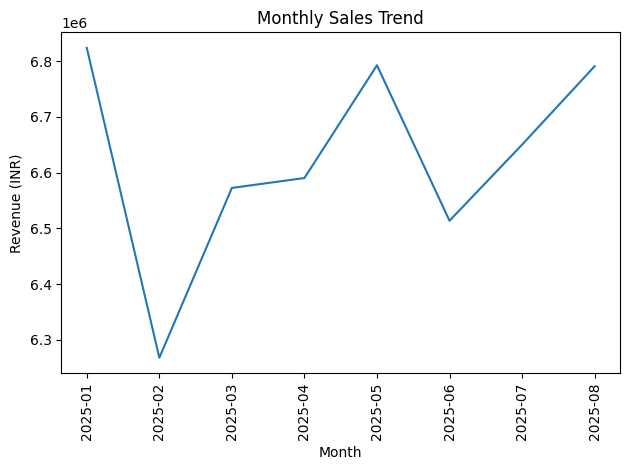

In [77]:
sns.lineplot(x="YearMonth",y="Price (INR)",data=monthly_revenue,markers="o")
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.tight_layout()
plt.show()

**Daily Sales Trend**

In [78]:
df["Day_name"]=df["Order Date"].dt.day_name()

daily_revenue=df.groupby("Day_name")["Price (INR)"].sum().reindex(["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]).reset_index()
daily_revenue

,Day_name,Price (INR)
0,Monday,7444475.14
1,Tuesday,7358996.01
2,Wednesday,7541692.52
3,Thursday,7663248.59
4,Friday,7579482.84
5,Saturday,7778260.40
6,Sunday,7636828.97


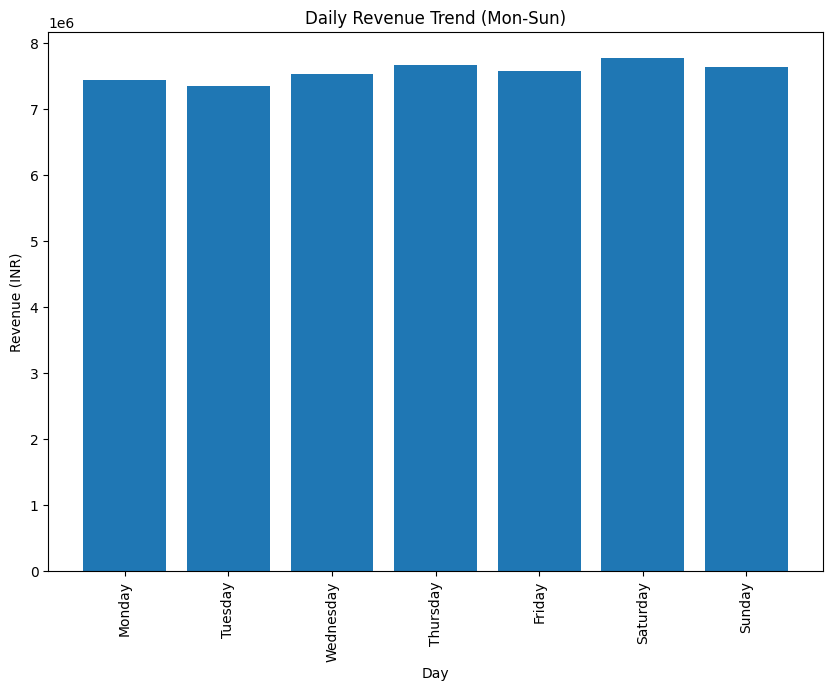

In [79]:
plt.figure(figsize=(10,7))
plt.bar(daily_revenue["Day_name"],daily_revenue["Price (INR)"])
plt.title("Daily Revenue Trend (Mon-Sun)")
plt.xlabel("Day")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=90)
plt.show()

**Total Sales by Category**

In [81]:
category_sales=df.groupby("Category")["Price (INR)"].sum().sort_values(ascending=False).reset_index()
category_sales.sort_values("Price (INR)",ascending=False)    
category_sales

,Category,Price (INR)
0,Recommended,7188272.53
1,Main Course,760045.00
2,Burger Combos ( 3 Pc Meals ),507773.55
3,McSaver Combos (2 Pc Meals),431336.65
4,Desserts,416172.28
...,...,...
4967,Bhaifota Special,25.00
4968,Water,20.00
4969,Add-ons,16.95
4970,Cool Drinks,14.00


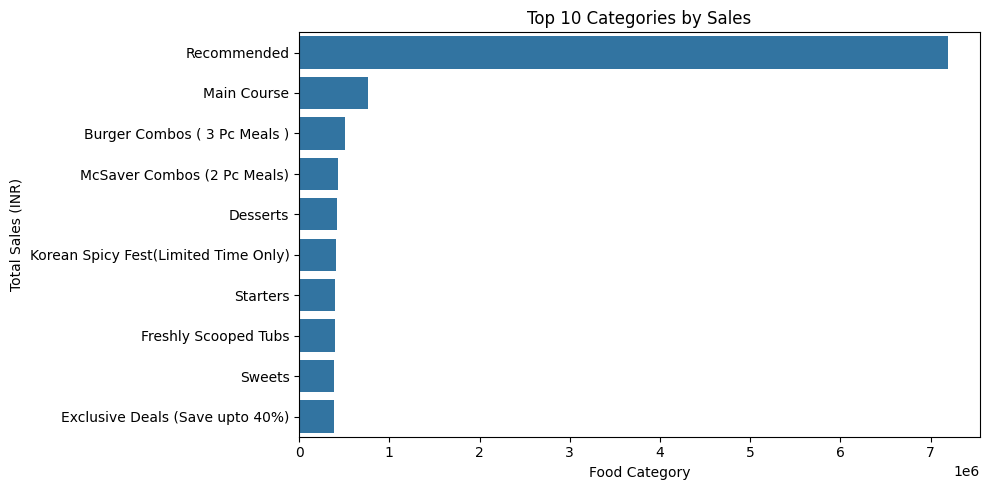

In [85]:
top10_category=category_sales.head(10)

plt.figure(figsize=(10,5))
sns.barplot(y="Category",x="Price (INR)",data=top10_category)
plt.title("Top 10 Categories by Sales")
plt.xlabel("Food Category",)
plt.ylabel("Total Sales (INR)")
plt.tight_layout()
plt.show()

**Total Sales by State**

In [90]:
State_sales=df.groupby("State")["Price (INR)"].sum().reset_index().sort_values("Price (INR)",ascending=False)
State_sales.head()

,State,Price (INR)
10,Karnataka,5455887.73
25,Uttar Pradesh,3117359.65
23,Telangana,3021711.62
13,Maharashtra,3015573.35
3,Delhi,2829180.60


In [93]:
top10_state=State_sales.head(10)

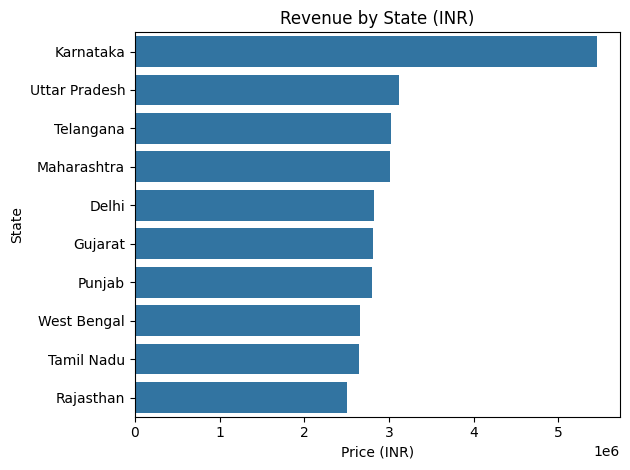

In [94]:
sns.barplot(x="Price (INR)",y="State",data=top10_state)
plt.title("Revenue by State (INR)")
plt.tight_layout()
plt.show()

**Quarterly Performance Summary**

In [96]:
df["Quarter"]=df["Order Date"].dt.to_period("Q")

Quarterly_summary=df.groupby("Quarter").agg({
    "Price (INR)":"sum","Rating":"mean","Order Date":"count"
})
Quarterly_summary.columns=["Total_Sales","Avg_Rating","Total_Orders"]
Quarterly_summary

,Total_Sales,Avg_Rating,Total_Orders
Quarter,,,
2025Q1,19664881.20,4.342638,73085
2025Q2,19896935.54,4.340008,74155
2025Q3,13441167.73,4.342358,50163


**Top 5 Cities by Sales**

In [101]:
City_sales=df.groupby("City")["Price (INR)"].sum().reset_index().sort_values("Price (INR)",ascending=False)
top5_city=City_sales.head()

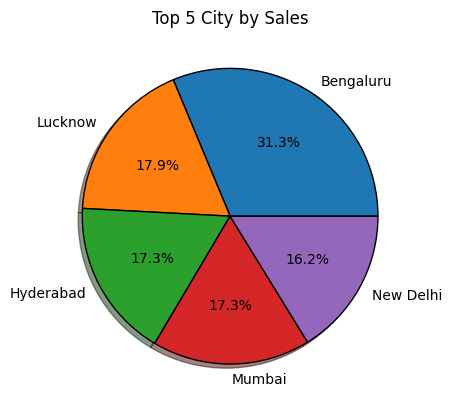

In [102]:
plt.pie(x=top5_city["Price (INR)"],labels=top5_city["City"],autopct="%0.1f%%",shadow=True,wedgeprops={"edgecolor":"black"})
plt.title("Top 5 City by Sales")
plt.show()

**Weekly Trend Analysis**

In [104]:
df["Week"]=df["Order Date"].dt.to_period("W").astype(str)

weekly_revenue=df.groupby("Week")["Price (INR)"].sum().reset_index()

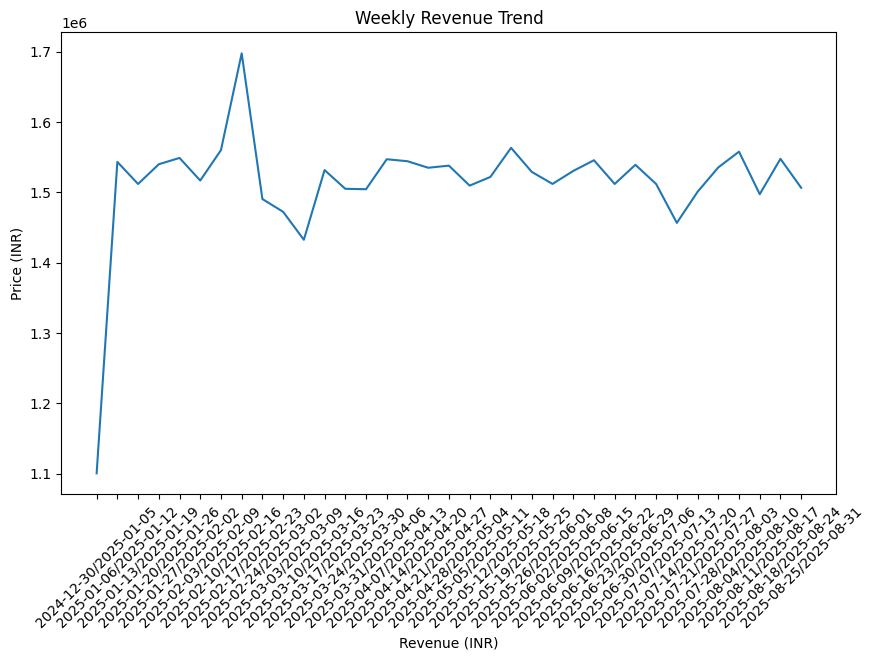

In [105]:
plt.figure(figsize=(10,6))
sns.lineplot(x="Week",y="Price (INR)",data=weekly_revenue)
plt.title("Weekly Revenue Trend")
plt.xlabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.show()

**Key Insights**

1. Bengaluru emerged as the highest revenue-generating city, contributing the largest share of total sales among the top-performing cities.

2. State-wise sales analysis revealed that a few states contributed significantly more revenue than others, indicating strong regional demand.

3. Category-wise analysis showed that certain food categories consistently generated higher sales, highlighting customer preferences and popular product segments.

4. Daily sales trends revealed fluctuations in revenue across different days, helping identify peak sales periods and customer ordering patterns.

5. Weekly trend analysis showed variations in sales performance, with some weeks recording noticeably higher revenue than others.

6. Quarterly performance analysis indicated changes in sales volume and revenue across quarters, providing insights into business growth and seasonal trends.

7. Customer ratings remained relatively stable throughout the period, suggesting consistent service quality and customer satisfaction.

8. Sales were concentrated in major metropolitan cities, demonstrating the importance of urban markets in overall revenue generation.

**Conclusion**

This Swiggy Sales Analysis project explored sales performance from multiple perspectives, including city-wise, state-wise, category-wise, daily, weekly, and quarterly trends. The analysis identified top-performing regions and categories while highlighting revenue patterns over time. Bengaluru emerged as the leading city in terms of sales contribution, and several food categories showed strong customer demand. Daily, weekly, and quarterly trend analyses provided valuable insights into sales fluctuations and business performance. These findings can support data-driven decision-making, targeted marketing strategies, and future business growth initiatives.